# Applying SVD, DMD, PySINDy, and SHRED

After preprocessing the daily covid19 data for US counties and rasterizing them, it is now time to apply the SVD, DMD, etc. models on these spatio-temporal data.

In [1]:
import rasterio
import numpy as np
import os

# Folder containing .tif files
raster_folder = 'raster_clipped'

# List of raster files
raster_files = sorted([os.path.join(raster_folder, f) for f in os.listdir(raster_folder) if f.endswith('.tif')])

# Initialize an array to hold the cumulative sum for batch processing (same size as individual rasters)
with rasterio.open(raster_files[0]) as src:
    # Get dimensions from the first raster
    height, width = src.height, src.width


# Initialize batch storage
raster_stack = []

for file in raster_files:
    with rasterio.open(file) as src:
        raster = src.read(1)  # Read the raster into memory (single band)
        raster_stack.append(raster)

# Convert batch to a numpy array (shape: batch_size, x, y)
raster_stack = np.array(raster_stack)

print(f"Stacked raster data shape: {raster_stack.shape}")

Stacked raster data shape: (1143, 310, 586)


In [2]:
# Identify invalid values and replace them with a clearly distinct value like -1
invalid_value_threshold = -1e+30  # Threshold to identify invalid values
raster_stack[raster_stack < invalid_value_threshold] = np.nan  # Mask invalid cells with NaN

# Replace NaN with -1 (or another value)
raster_stack = np.nan_to_num(raster_stack, nan=-1)  

# SVD

In [7]:
from numpy.linalg import svd

raster_stack_reshaped = raster_stack.reshape(raster_stack.shape[0], -1)

# Apply SVD
U, S, Vt = svd(raster_stack_reshaped, full_matrices=False)

C:\Users\babak\AppData\Local\Temp\ipykernel_19280\2842456674.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


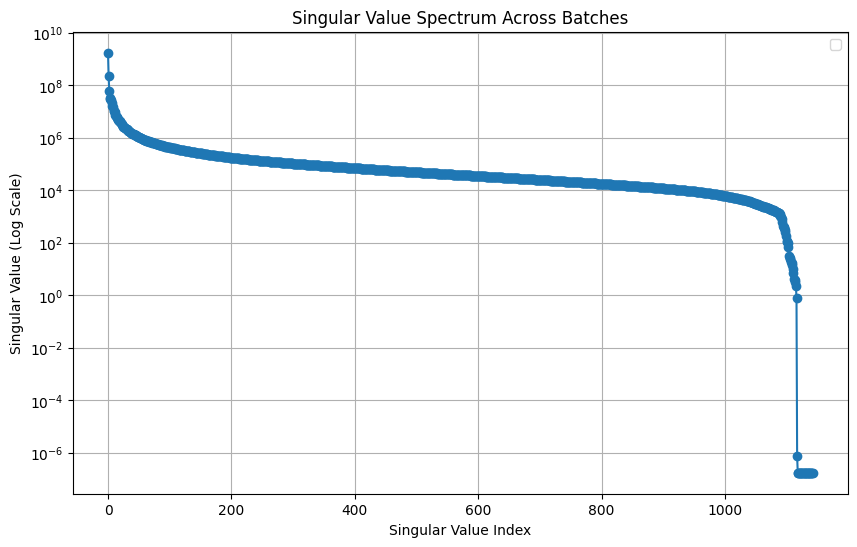

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(S, marker='o')
    
plt.yscale('log')
plt.title('Singular Value Spectrum Across Batches')
plt.xlabel('Singular Value Index')
plt.ylabel('Singular Value (Log Scale)')
plt.legend()
plt.grid(True)
plt.show()

# Reconstructing data with SVD

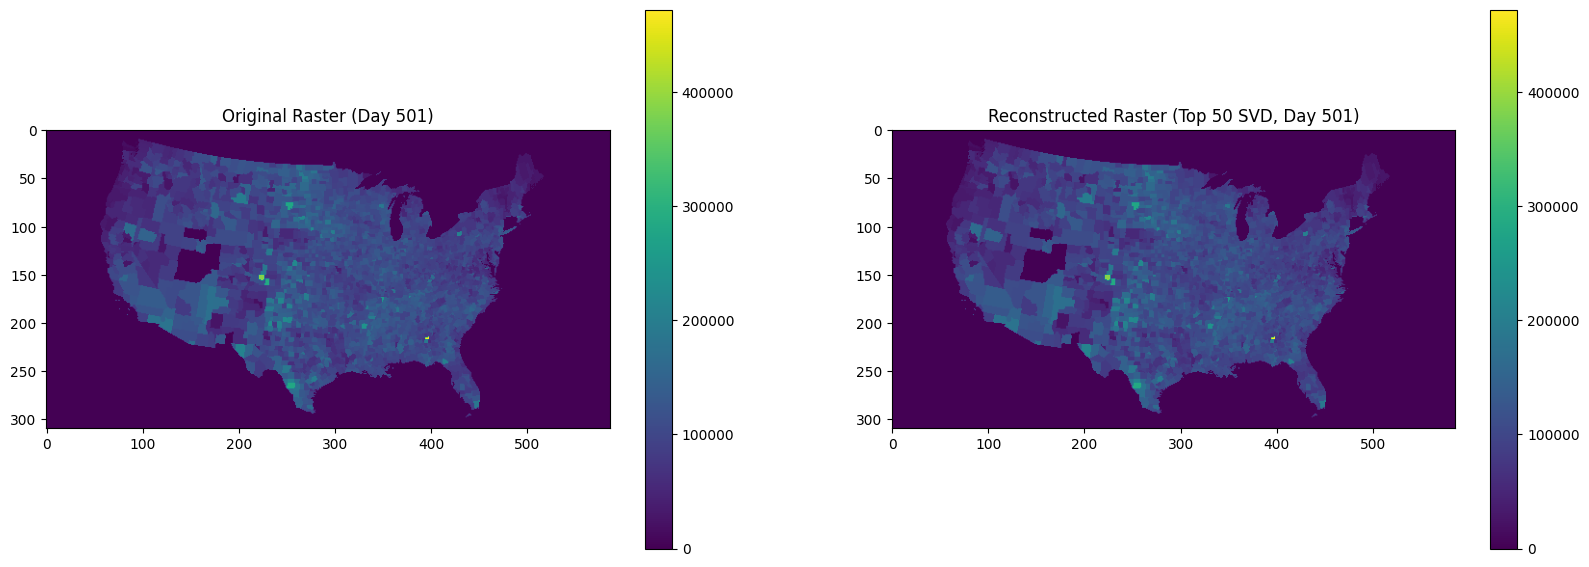

Reconstruction Error (MSE) for Day 501: 64804.75390625


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Select the number of singular values/components to use in reconstruction
num_components = 50 

# Reconstruct the raster stack using the first 'num_components' components
S_reduced = np.diag(S[:num_components])
U_reduced = U[:, :num_components]
Vt_reduced = Vt[:num_components, :]

raster_stack_reconstructed = np.dot(U_reduced, np.dot(S_reduced, Vt_reduced))
raster_stack_reconstructed = raster_stack_reconstructed.reshape(raster_stack.shape)

# Visualize the original and reconstructed raster for a specific day 
day_index = 500

original_day = raster_stack[day_index]
reconstructed_day = raster_stack_reconstructed[day_index]

vmin = min(np.min(original_day), np.min(reconstructed_day))
vmax = max(np.max(original_day), np.max(reconstructed_day))

plt.figure(figsize=(20, 7))

# Original raster
plt.subplot(1, 2, 1)
plt.imshow(original_day, cmap='viridis', vmin=vmin, vmax=vmax)
plt.colorbar()
plt.title(f'Original Raster (Day {day_index + 1})')

# Reconstructed raster
plt.subplot(1, 2, 2)
plt.imshow(reconstructed_day, cmap='viridis', vmin=vmin, vmax=vmax)
plt.colorbar()
plt.title(f'Reconstructed Raster (Top {num_components} SVD, Day {day_index + 1})')

plt.show()

# Calculate and print reconstruction error
reconstruction_error = np.mean((raster_stack[day_index] - raster_stack_reconstructed[day_index]) ** 2)
print(f"Reconstruction Error (MSE) for Day {day_index + 1}: {reconstruction_error}")

Reconstruction Error (MSE) for all days: [np.float32(0.57200426), np.float32(0.57200426), np.float32(0.57200813), np.float32(0.57200813), np.float32(0.57207215), np.float32(0.57207215), np.float32(0.57207215), np.float32(0.57207215), np.float32(0.57207215), np.float32(0.5721222), np.float32(0.5721222), np.float32(0.5721222), np.float32(0.76574016), np.float32(0.76574016), np.float32(0.76574016), np.float32(0.76616544), np.float32(0.76616544), np.float32(0.76616544), np.float32(0.76616544), np.float32(0.76616544), np.float32(0.7661687), np.float32(0.7661687), np.float32(0.76626706), np.float32(0.76626706), np.float32(0.57610524), np.float32(0.57610524), np.float32(0.5813444), np.float32(0.5914495), np.float32(0.5914495), np.float32(0.5914495), np.float32(0.5914495), np.float32(0.5914495), np.float32(0.5914495), np.float32(0.5915777), np.float32(0.5927384), np.float32(0.5947064), np.float32(0.5947064), np.float32(0.5947064), np.float32(0.5981529), np.float32(0.60457927), np.float32(0.754

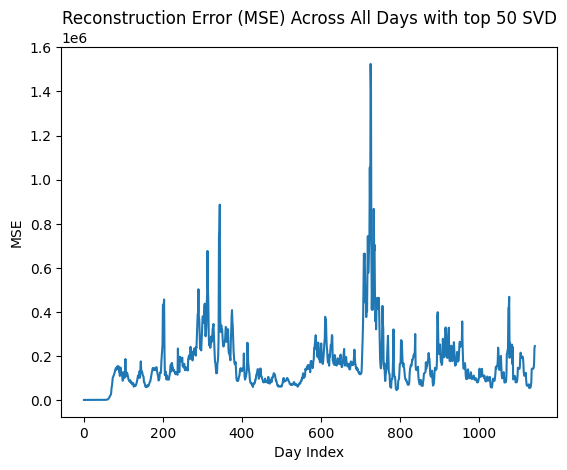

In [6]:
# Calculate the reconstruction error (MSE) for each day
errors = []
for i in range(raster_stack.shape[0]):  # Loop over all 1143 days
    error = np.mean((raster_stack[i] - raster_stack_reconstructed[i]) ** 2)
    errors.append(error)

# Print and plot the errors across all days
print(f"Reconstruction Error (MSE) for all days: {errors}")
plt.plot(errors)
plt.title("Reconstruction Error (MSE) Across All Days with top 50 SVD")
plt.xlabel("Day Index")
plt.ylabel("MSE")
plt.show()


# Visualizing Dominant Spatial Patterns

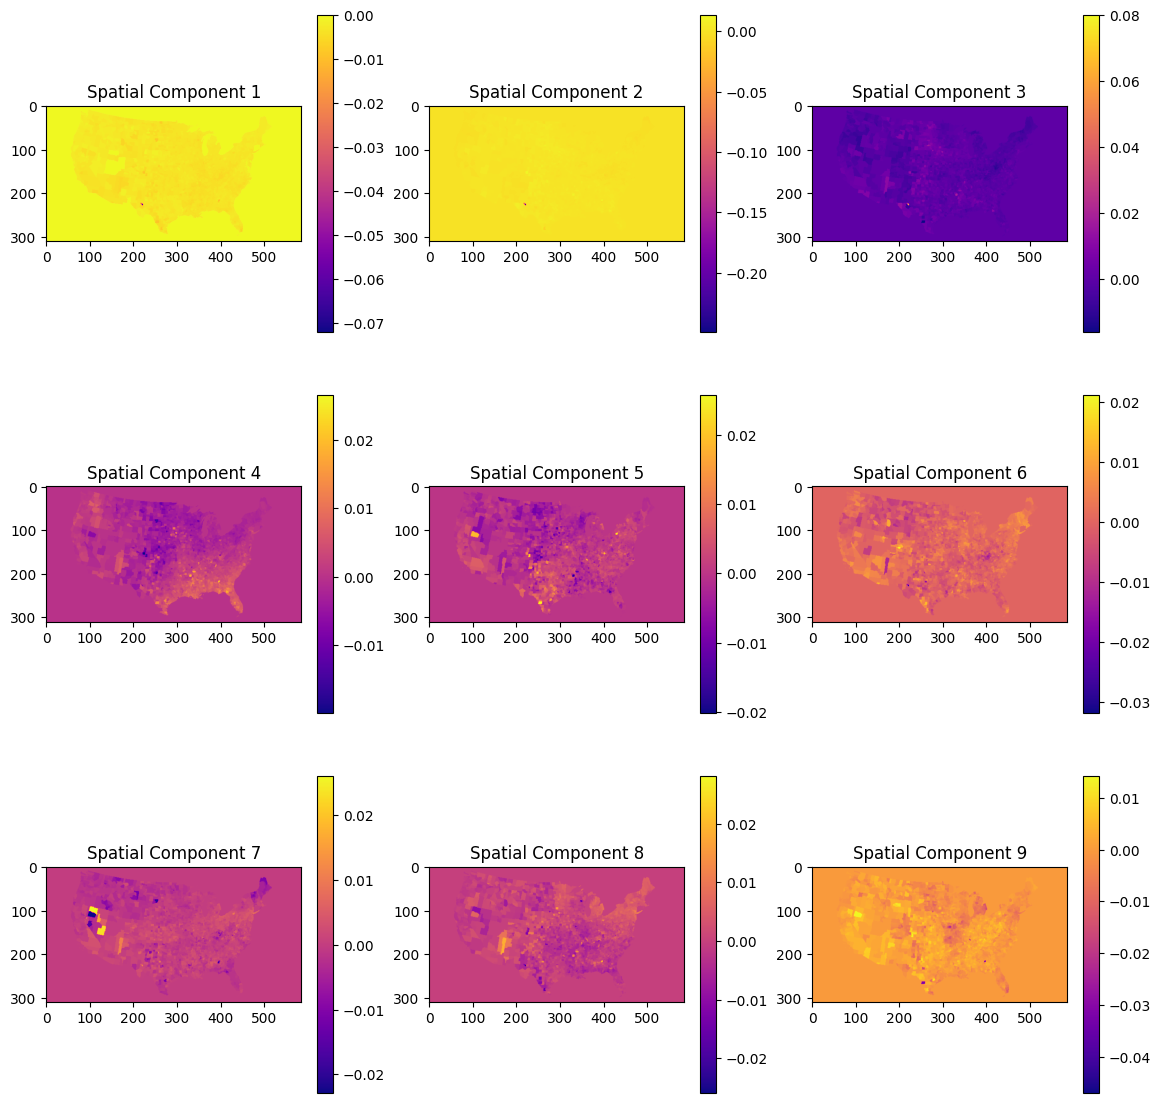

In [7]:
import matplotlib.pyplot as plt

num_components = 9  # Number of spatial components

# Reshape and plot all components in a loop
plt.figure(figsize=(14, 14))
for i in range(num_components):
    spatial_component = Vt[i, :]
    height, width = 310, 586
    spatial_component_reshaped = spatial_component.reshape(height, width)

    plt.subplot(3, 3, i+1)  # Adjust subplot indexing for proper layout
    plt.imshow(spatial_component_reshaped, cmap='plasma')
    plt.title(f'Spatial Component {i+1}')  # Use f-string for dynamic titles
    plt.colorbar()

plt.show()

# Making an Animation of the Raster Files for All Days

With the animation we can see and verify the validity of spatial components

MovieWriter imagemagick unavailable; using Pillow instead.


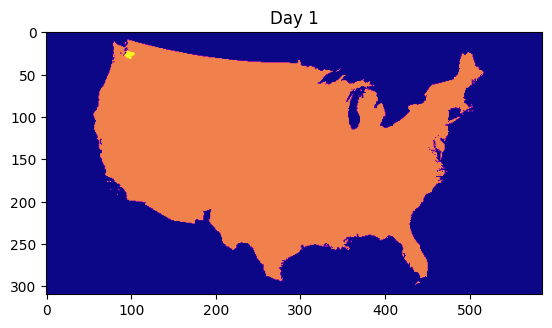

In [8]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def plot_raster(i, raster_stack, ax):
    ax.clear()  # Clear the previous plot
    ax.imshow(raster_stack[i], cmap='plasma')  # Adjust cmap as needed
    ax.set_title(f'Day {i+1}')
    return ax

fig, ax = plt.subplots()
anim = FuncAnimation(fig, plot_raster, frames=len(raster_stack), fargs=(raster_stack, ax))

# Save the animation as a GIF
anim.save('us_daily_covid19_animation.gif', writer='imagemagick')

# Visualizing Temporal Patterns

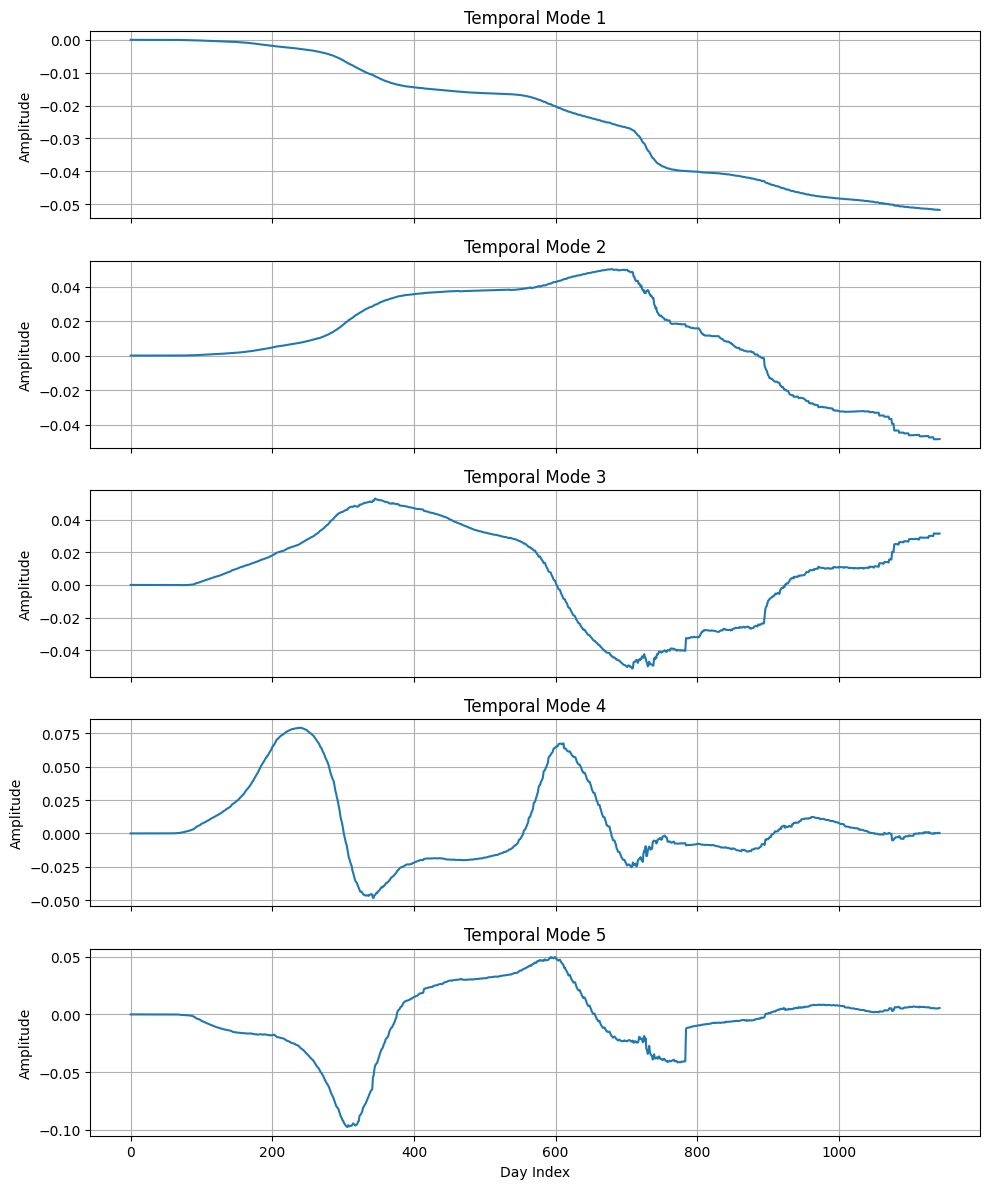

In [9]:
import matplotlib.pyplot as plt

# Let's say we want to plot the first 5 modes from the U matrix
num_modes_to_plot = 5

# Create subplots for each mode
fig, axes = plt.subplots(num_modes_to_plot, 1, figsize=(10, 12), sharex=True)

for i in range(num_modes_to_plot):
    axes[i].plot(U[:, i])  # Plot the i-th mode
    axes[i].set_title(f'Temporal Mode {i + 1}')
    axes[i].set_ylabel('Amplitude')
    axes[i].grid(True)

# Set the x-label for the last subplot
axes[-1].set_xlabel('Day Index')

plt.tight_layout()
plt.show()

# Applying DMD

In [23]:
import numpy as np
from scipy.linalg import svd, eig

# Create a mask that identifies valid data points (where values are not -1)
#valid_mask = raster_stack[0] != -1  # Assuming the mask is the same across all time steps

# Apply the mask for all time steps
#masked_raster_stack = raster_stack[:, valid_mask]  # Keep only valid pixels for all time steps

# Prepare the datasets X and X_prime (shifted by one timestep)
#X = masked_raster_stack[:-1].reshape(1142, -1).T  # Exclude last time step, and transpose to shape (spatial_points, time_steps - 1)
#X_prime = masked_raster_stack[1:].reshape(1142, -1).T  # Exclude first time step, and transpose

X = raster_stack[:-1].reshape(1142, -1).T  # Shape: (spatial_points, time_steps - 1)
X_prime = raster_stack[1:].reshape(1142, -1).T  # Shape: (spatial_points, time_steps - 1)

X[np.isnan(X)] = 0
X_prime[np.isnan(X_prime)] = 0

# Perform SVD on X
U, S, Vt = svd(X, full_matrices=False)

# Low-rank truncation
r = min(50, len(S))  # rank (r)
U_r = U[:, :r]
S_r = np.diag(S[:r])
V_r = Vt.T[:, :r]

# Compute matrix Atilde (reduced system dynamics)
A_tilde = U_r.T @ X_prime @ V_r @ np.linalg.inv(S_r)

# Eigen-decomposition of Atilde
eigenvalues, W = eig(A_tilde)
Phi = X_prime @ V_r @ np.linalg.inv(S_r) @ W  # DMD modes

# Compute DMD temporal evolution (b) and reconstruction
b = np.linalg.lstsq(Phi, X[:, 0], rcond=None)[0]

# Reconstruct the data using DMD
time_dynamics = np.zeros((r, X.shape[1]), dtype=complex)
for i in range(X.shape[1]):
    time_dynamics[:, i] = b * np.exp(eigenvalues * i)

X_dmd = Phi @ time_dynamics
X_dmd = X_dmd.real.T.reshape(1142, 310, 586)  # Reshape back to original size

C:\Users\babak\AppData\Local\Temp\ipykernel_19280\1579452827.py:42: RuntimeWarning: overflow encountered in multiply
  time_dynamics[:, i] = b * np.exp(eigenvalues * i)
C:\Users\babak\AppData\Local\Temp\ipykernel_19280\1579452827.py:42: RuntimeWarning: overflow encountered in exp
  time_dynamics[:, i] = b * np.exp(eigenvalues * i)
C:\Users\babak\AppData\Local\Temp\ipykernel_19280\1579452827.py:42: RuntimeWarning: invalid value encountered in multiply
  time_dynamics[:, i] = b * np.exp(eigenvalues * i)


Unfortunately I could not get the DMD to work on the covid 19 data properly. It seems that since the images are rectangular while the boundaries of the US is not rectangular (As all natural countries and boundaries are not :) ), the sourounding pixels around US boundaries with no value make it challenging for DMD to work properly. I also created a subset of the images a rectangular area inside US to avoid passing NaN pixels to DMD but again it was not successful.

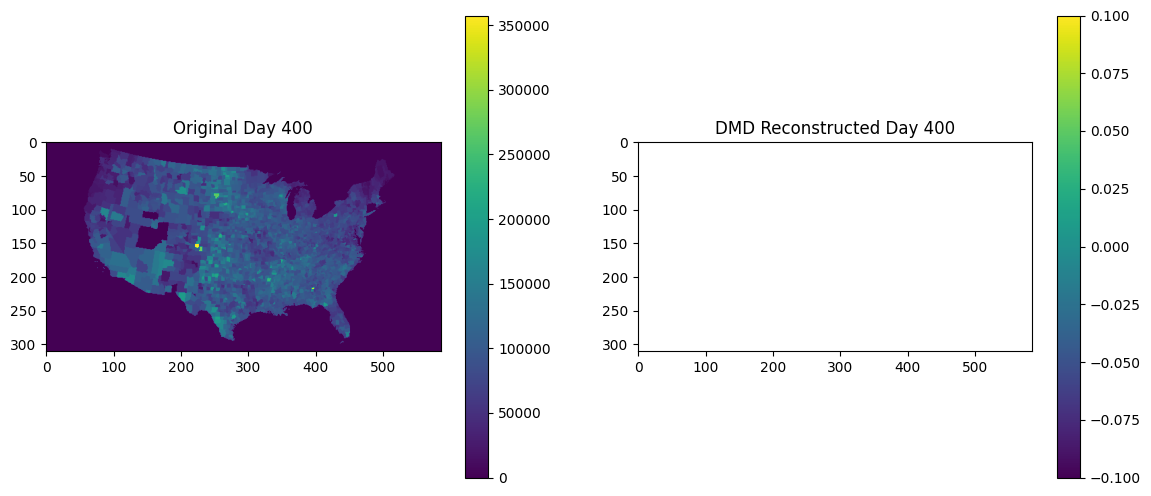

In [24]:
import matplotlib.pyplot as plt

# Plot some reconstructed DMD frames (compare with original)
day_index = 400  # Select a day to compare
original_day = raster_stack[day_index]
dmd_reconstructed_day = X_dmd[day_index]

# Plot original vs DMD reconstruction
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(original_day, cmap='viridis')
plt.colorbar()
plt.title(f'Original Day {day_index}')

plt.subplot(1, 2, 2)
plt.imshow(dmd_reconstructed_day, cmap='viridis')
plt.colorbar()
plt.title(f'DMD Reconstructed Day {day_index}')
plt.show()

# Ploting Eigenvalues

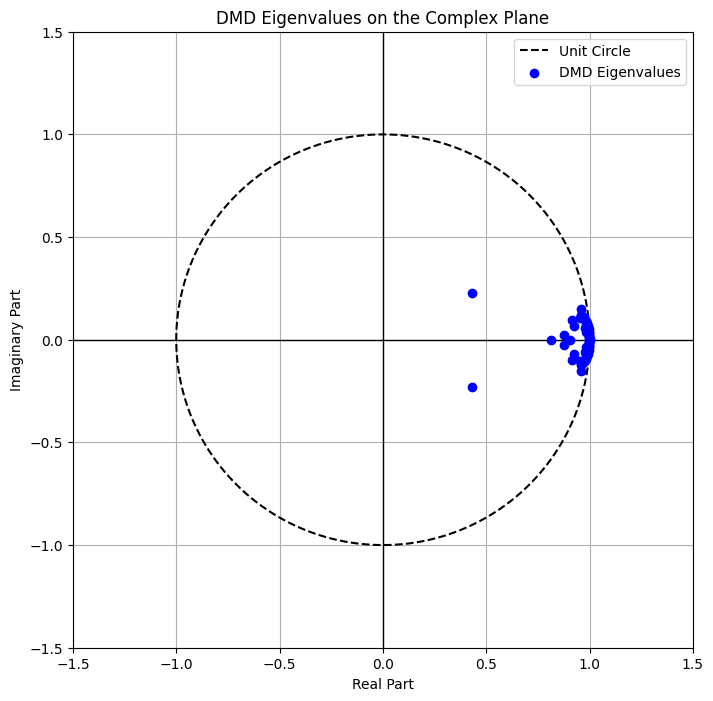

In [16]:
import matplotlib.pyplot as plt
import numpy as np

real_part = np.real(eigenvalues)
imag_part = np.imag(eigenvalues)

# Create a unit circle for reference
unit_circle = np.exp(1j * np.linspace(0, 2 * np.pi, 1000))

# Plot the eigenvalues on the complex plane
plt.figure(figsize=(8, 8))
plt.plot(np.real(unit_circle), np.imag(unit_circle), 'k--', label='Unit Circle')  # Plot the unit circle
plt.scatter(real_part, imag_part, color='b', label='DMD Eigenvalues', zorder=5)

# Set the axes limits to keep the plot squared and focus on the region near the unit circle
plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])

plt.axhline(0, color='black',linewidth=1)  # Add x-axis
plt.axvline(0, color='black',linewidth=1)  # Add y-axis

plt.title('DMD Eigenvalues on the Complex Plane')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.grid(True)
plt.legend()
plt.show()

# Creating a Rectangular Subset

In [40]:
raster_stack_subset = raster_stack[:, 50:-100, 200:-280]

# Check the new shape of the subset
print("New shape of raster stack subset:", raster_stack_subset.shape)

New shape of raster stack subset: (1143, 160, 106)


In [41]:
import numpy as np
from scipy.linalg import svd, eig

# Prepare the datasets X and X_prime (shifted by one timestep)
X = raster_stack_subset[:-1].reshape(1142, -1).T  
X_prime = raster_stack_subset[1:].reshape(1142, -1).T  

X[np.isnan(X)] = 0
X_prime[np.isnan(X_prime)] = 0

# Perform SVD on X
U, S, Vt = svd(X, full_matrices=False)

# Low-rank truncation
r = min(50, len(S))  
U_r = U[:, :r]
S_r = np.diag(S[:r])
V_r = Vt.T[:, :r]

# Compute matrix Atilde (reduced system dynamics)
A_tilde = U_r.T @ X_prime @ V_r @ np.linalg.inv(S_r)

# Eigen-decomposition of Atilde
eigenvalues, W = eig(A_tilde)
Phi = X_prime @ V_r @ np.linalg.inv(S_r) @ W  # DMD modes

# Compute DMD temporal evolution (b) and reconstruction
b = np.linalg.lstsq(Phi, X[:, 0], rcond=None)[0]

# Reconstruct the data using DMD
time_dynamics = np.zeros((r, X.shape[1]), dtype=complex)
for i in range(X.shape[1]):
    time_dynamics[:, i] = b * np.exp(eigenvalues * i)

X_dmd = Phi @ time_dynamics
X_dmd = X_dmd.real.T.reshape(1142, 160, 106)  # Reshape back to original size

C:\Users\babak\AppData\Local\Temp\ipykernel_19280\1627751403.py:42: RuntimeWarning: overflow encountered in exp
  time_dynamics[:, i] = b * np.exp(eigenvalues * i)
C:\Users\babak\AppData\Local\Temp\ipykernel_19280\1627751403.py:42: RuntimeWarning: invalid value encountered in multiply
  time_dynamics[:, i] = b * np.exp(eigenvalues * i)


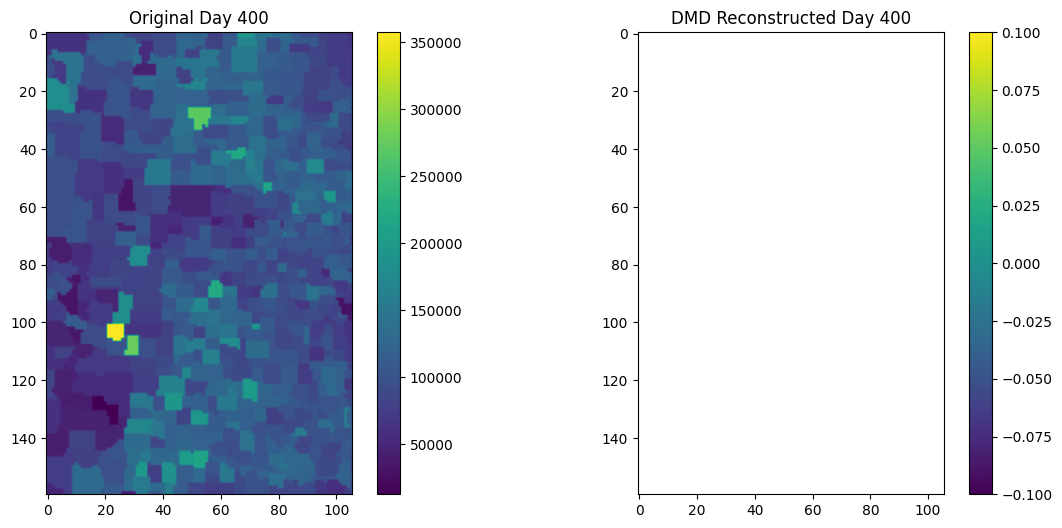

In [42]:
import matplotlib.pyplot as plt

# Plot some reconstructed DMD frames (compare with original)
day_index = 2  # Select a day to compare
original_day = raster_stack_subset[day_index]
dmd_reconstructed_day = X_dmd[day_index]

# Plot original vs DMD reconstruction
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(original_day, cmap='viridis')
plt.colorbar()
plt.title(f'Original Day {day_index}')

plt.subplot(1, 2, 2)
plt.imshow(dmd_reconstructed_day, cmap='viridis')
plt.colorbar()
plt.title(f'DMD Reconstructed Day {day_index}')
plt.show()

# Using pyDMD Library

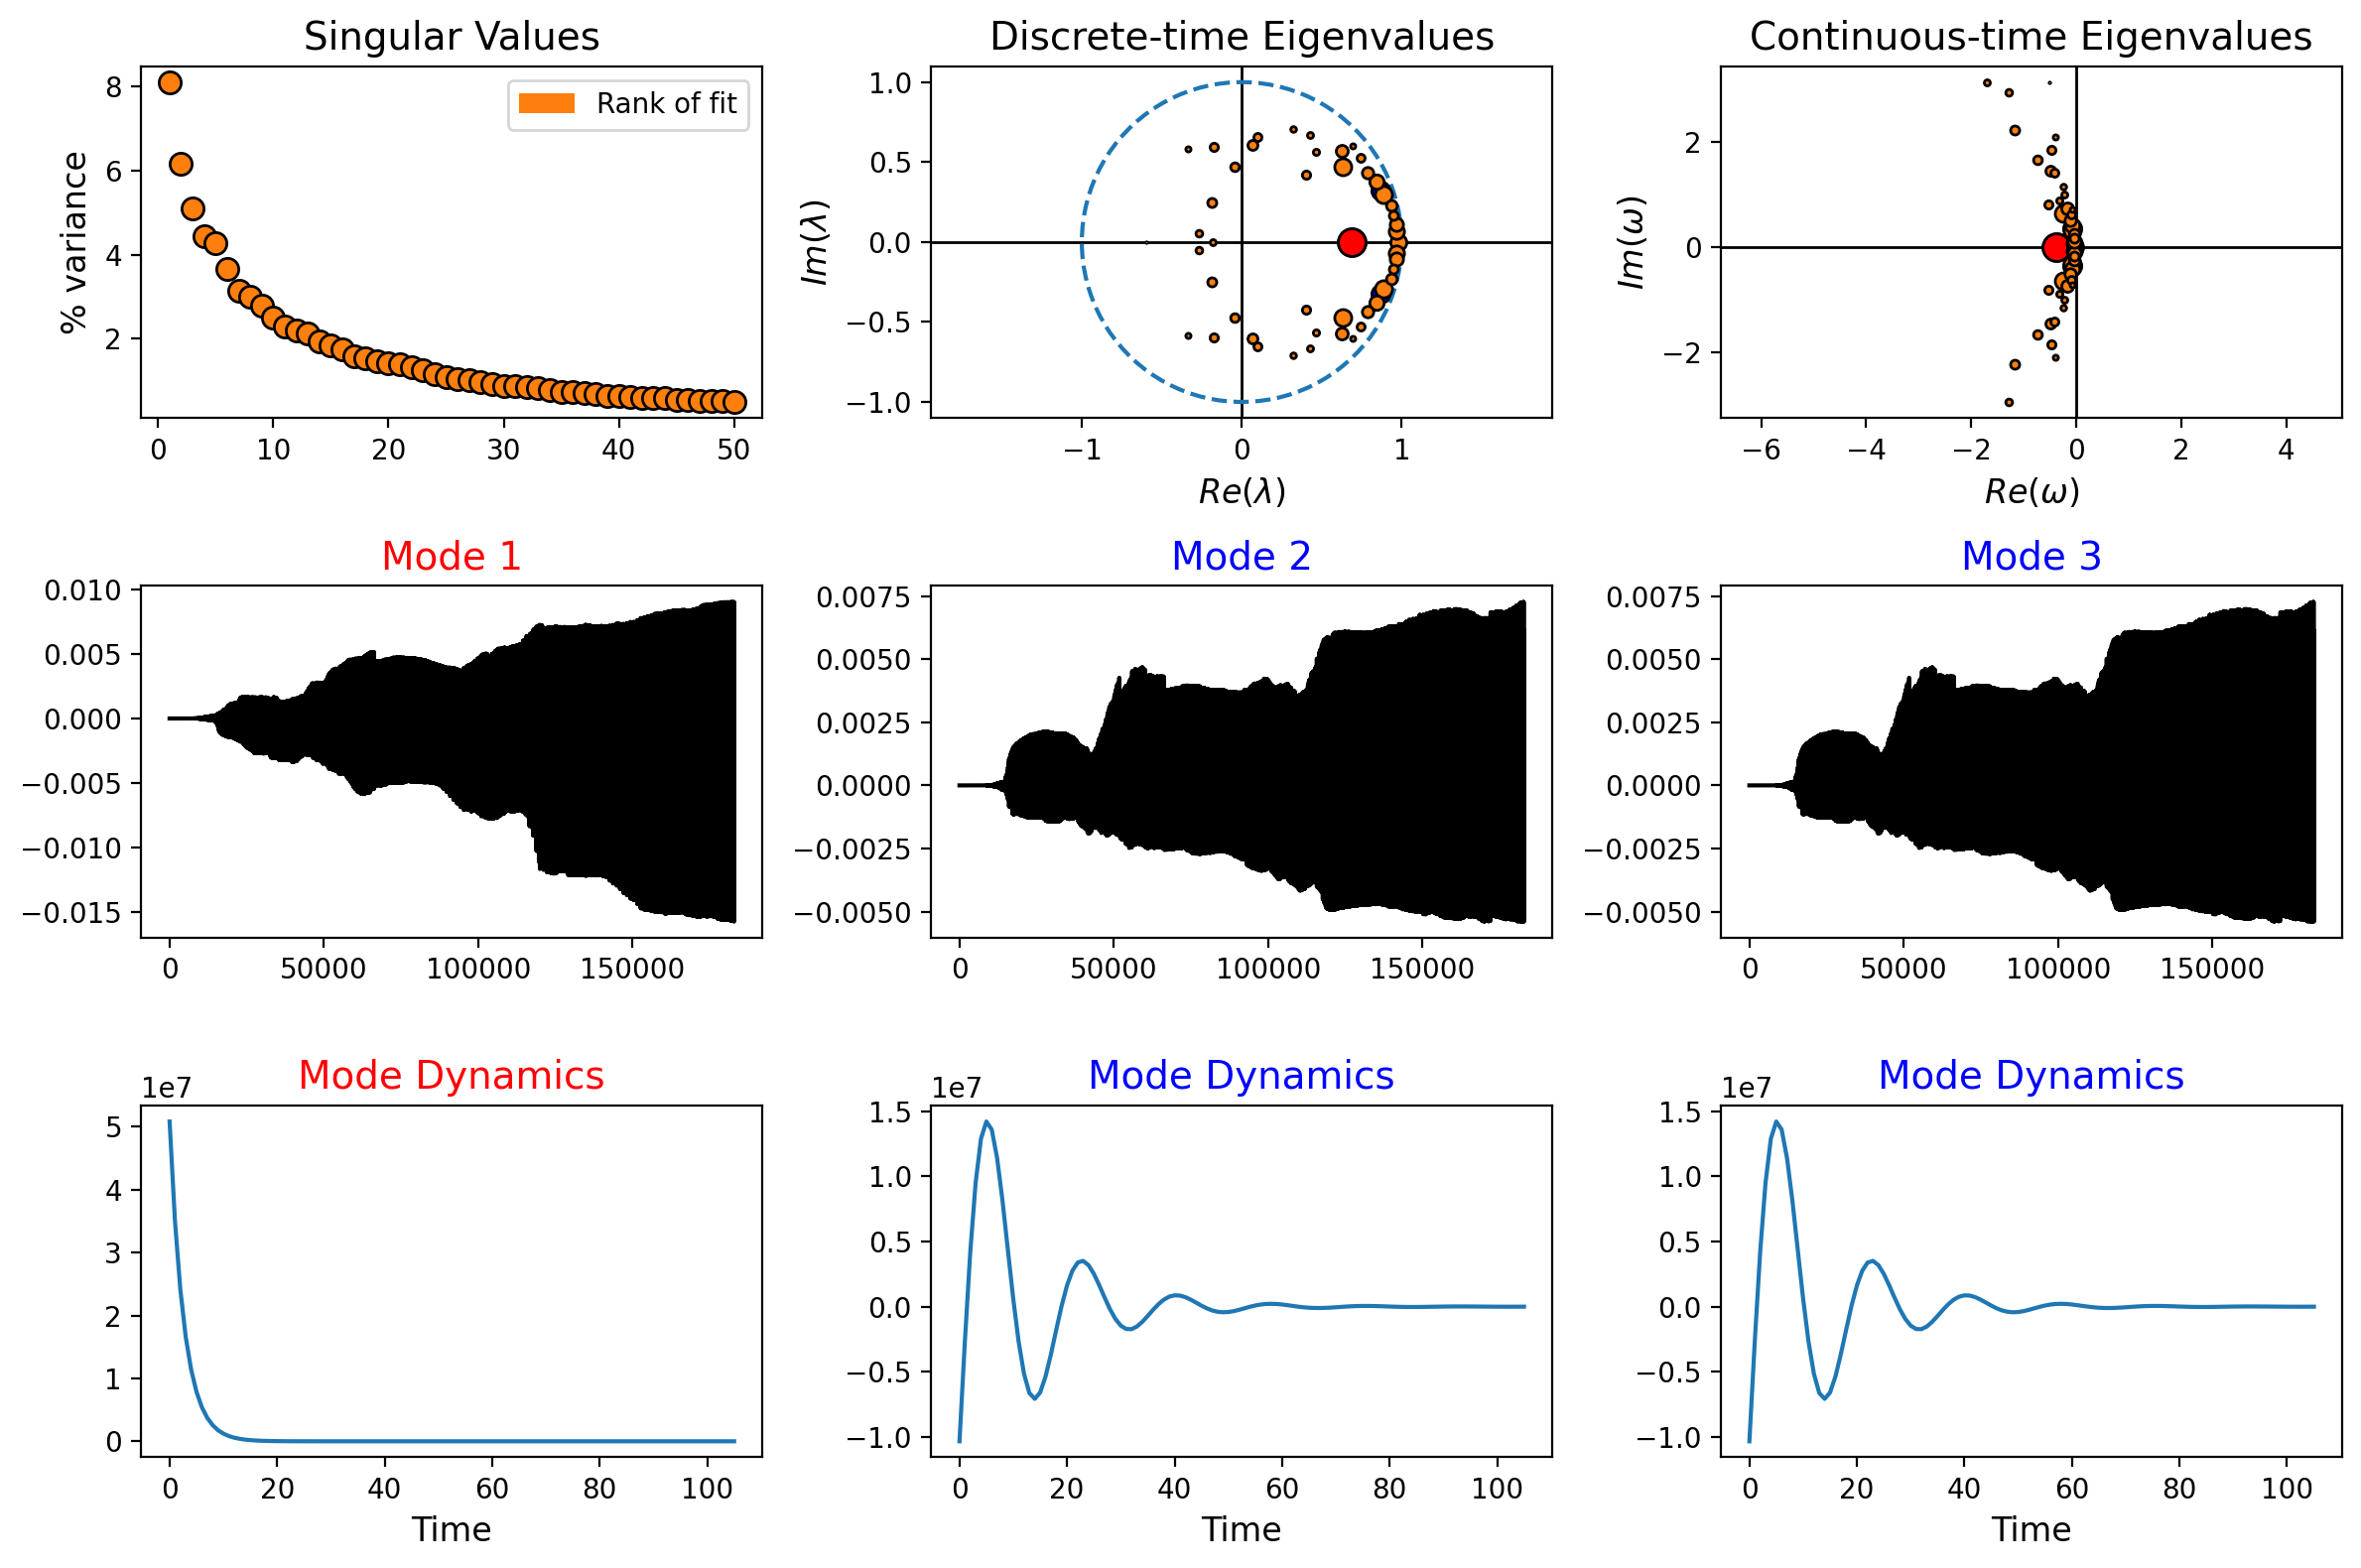

In [48]:
from pydmd import DMD
from pydmd.plotter import plot_summary
from pydmd.preprocessing import zero_mean_preprocessing

raster_stack_reshaped = raster_stack_subset.reshape(1143, -1).T  # Shape: (spatial_points, time_steps)

# Build and fit an exact DMD model with data centering.
centered_dmd = zero_mean_preprocessing(DMD(svd_rank=50))
centered_dmd.fit(raster_stack_subset)
#centered_dmd.fit(raster_stack_reshaped)

#dmd = DMD(svd_rank=50) 
#dmd.fit(raster_stack_reshaped)

plot_summary(centered_dmd)

d:\Polimi\Courses\modeling from measurements\.venv\Lib\site-packages\pydmd\snapshots.py:73: UserWarning: Input data condition number 9.16474642870548e+20. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


Step 1 Error 0.007072161648246671 Lambda 8388608.0
Convergence reached!

Displaying the results of the next 5 trials...

Step 1 Error 0.0067885927746718835 Lambda 1048576.0
Convergence reached!

Step 1 Error 0.006445584110902531 Lambda 2251799813685248.0
Convergence reached!

Step 1 Error 0.0071224431051304425 Lambda 67108864.0
Convergence reached!

Step 1 Error 0.006993771920309341 Lambda 4194304.0
Convergence reached!

Step 1 Error 0.006416877640058254 Lambda 1048576.0
Convergence reached!



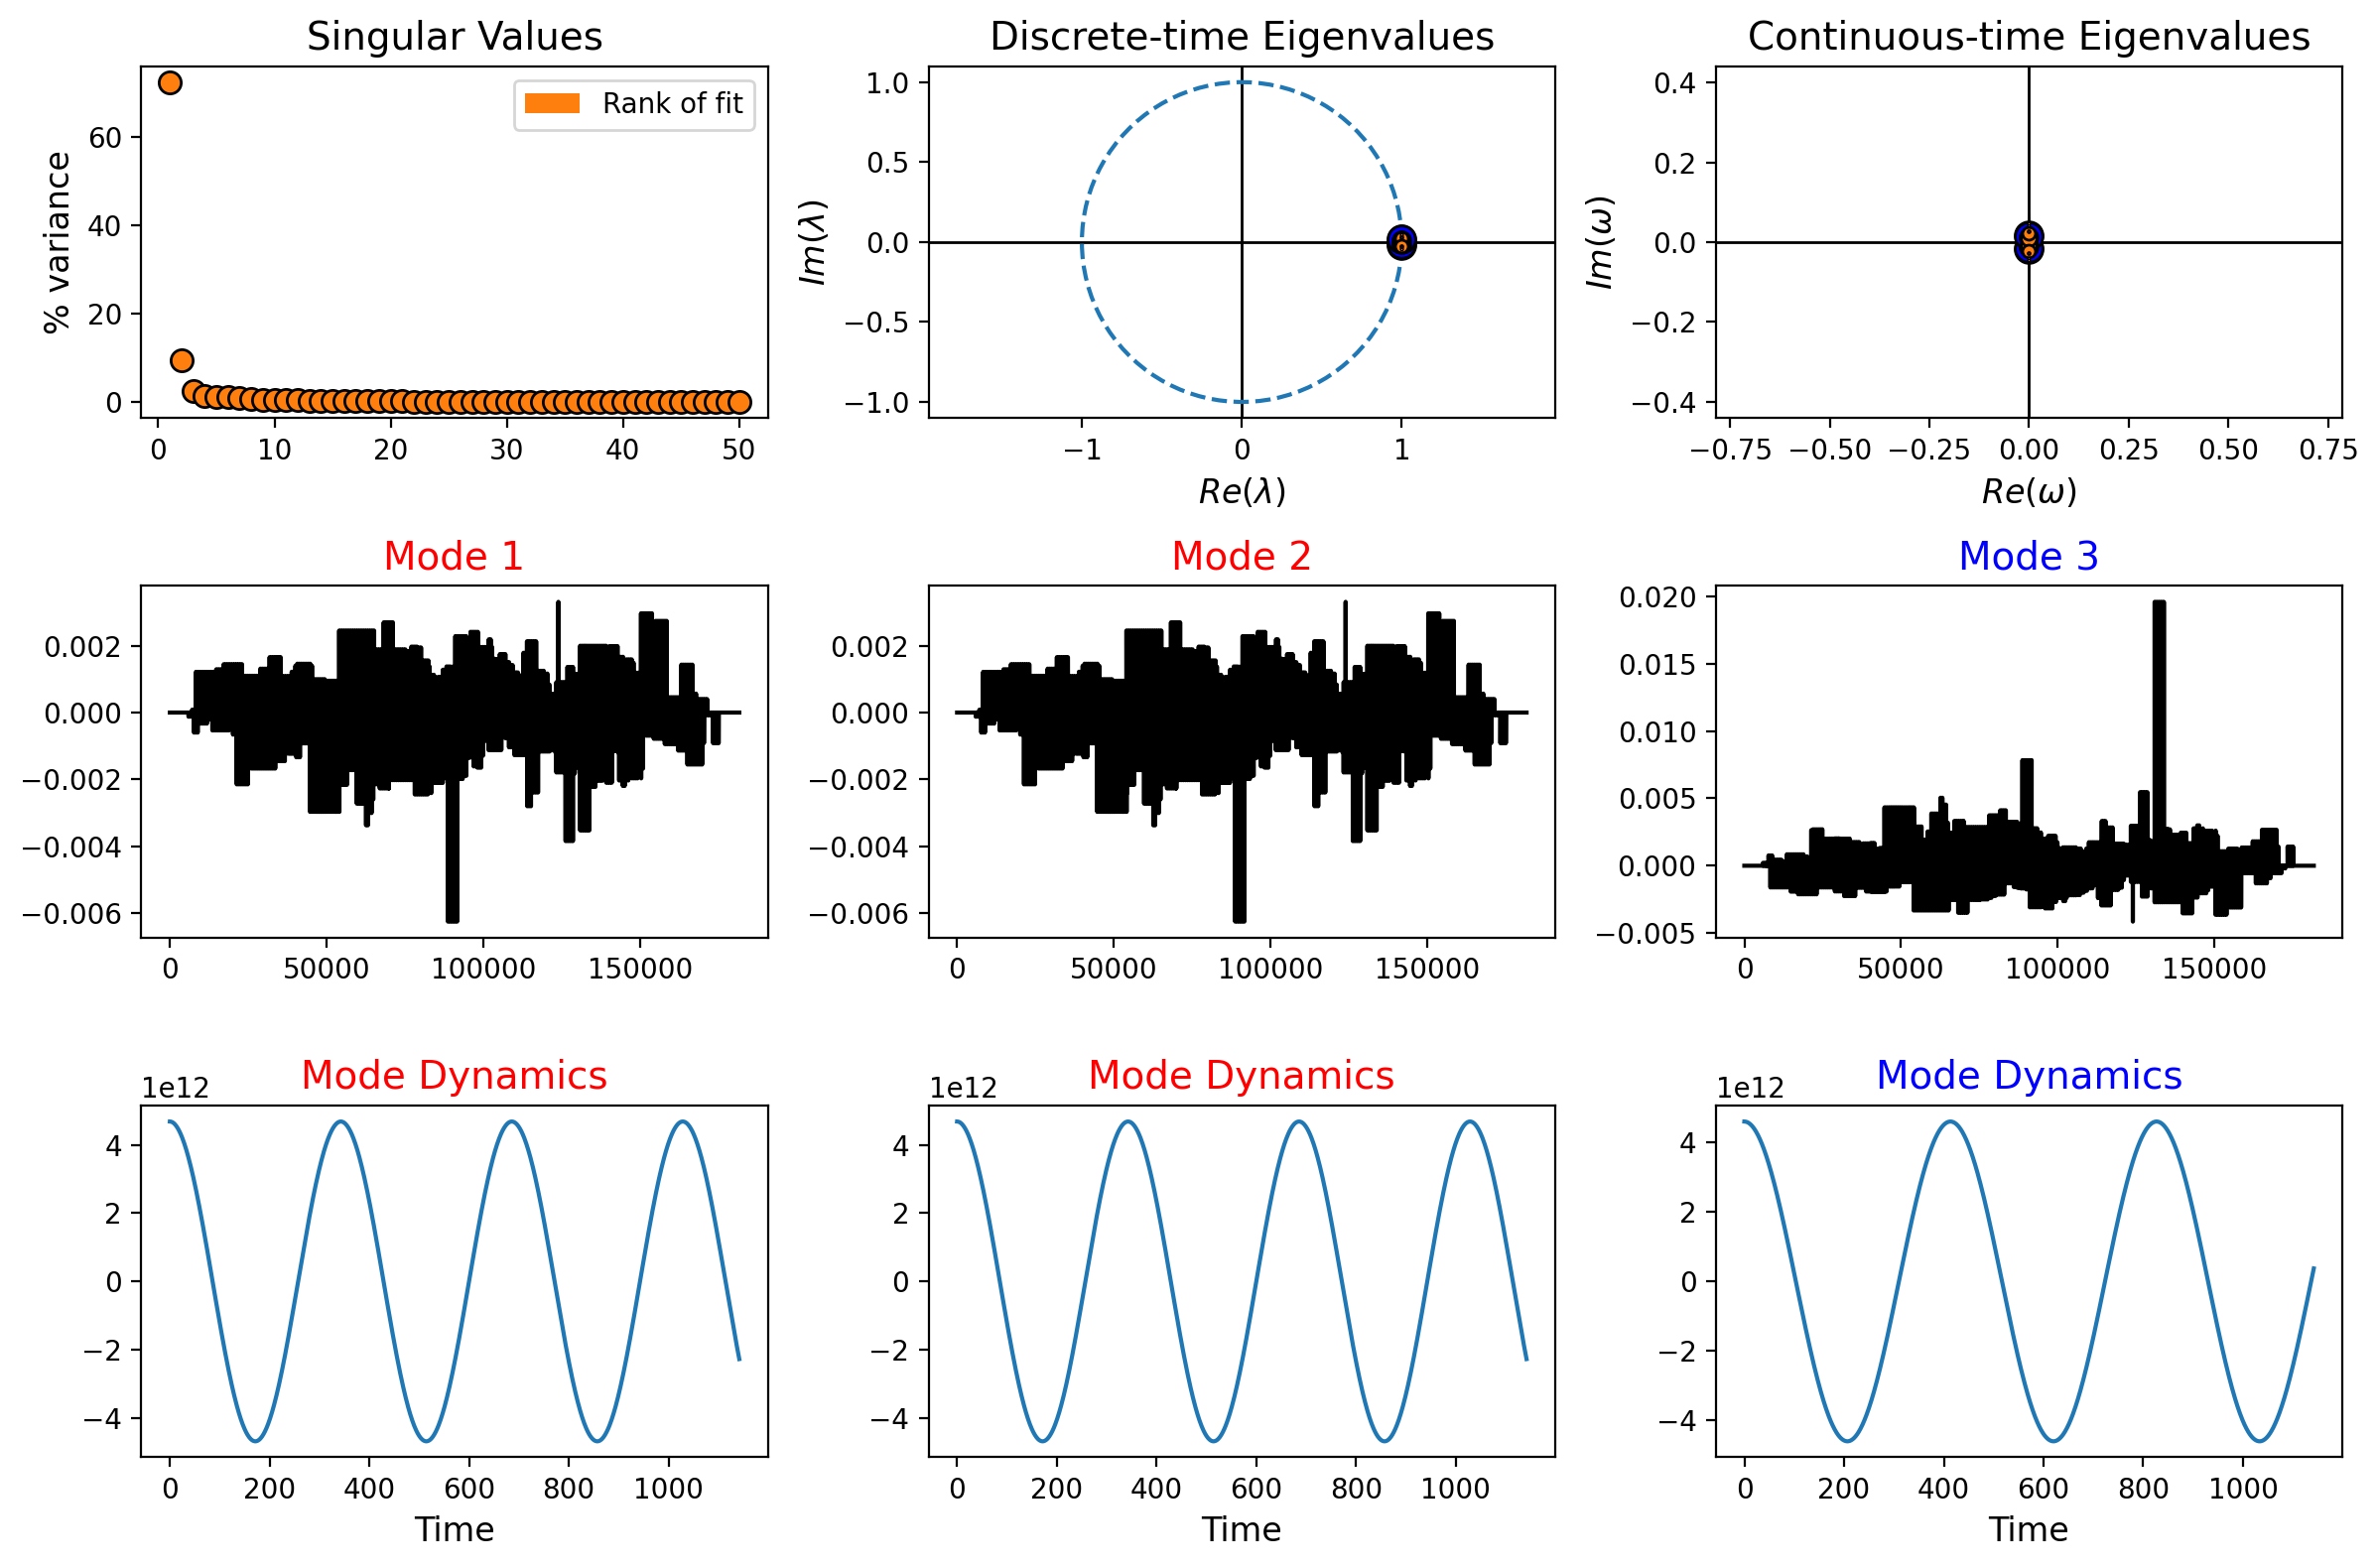

In [55]:
from pydmd import BOPDMD

# Build a Bagging, Optimized DMD (BOP-DMD) model.
# For Optimized DMD (without bagging), use BOPDMD(svd_rank=12, num_trials=0).
bopdmd = BOPDMD(
    svd_rank=50,                                  # Rank of the DMD fit.
    num_trials=100,                               # Number of bagging trials to perform.
    trial_size=0.5,                               # Use 50% of the total number of snapshots per trial.
    eig_constraints={"imag", "conjugate_pairs"},  # Eigenvalues must be imaginary and conjugate pairs.
    varpro_opts_dict={"tol":0.2, "verbose":True}, # Set convergence tolerance and use verbose updates.
)

# Fit the BOP-DMD model.
raster_stack_reshaped = raster_stack.reshape(1143, -1).T
t = np.arange(raster_stack.shape[0])
bopdmd.fit(raster_stack_reshaped, t)

#raster_stack_reshaped = raster_stack_subset.reshape(1143, -1).T
#t = np.arange(raster_stack_subset.shape[0])
#bopdmd.fit(raster_stack_reshaped, t)

plot_summary(bopdmd)

# Applying SINDy

In [3]:
import numpy as np

# Flatten the raster stack into (time, spatial_points)
flattened_raster_stack = raster_stack.reshape(raster_stack.shape[0], -1)  # Shape: (1143, 310 * 586)

# Calculate numerical derivatives (finite differences to approximate time derivatives)
time_derivative = np.gradient(flattened_raster_stack, axis=0)  # Derivative w.r.t time

# X should be (samples, features), i.e., (1143, 181660)
X = flattened_raster_stack  # No need to transpose since it's already in correct shape

# X_dot should match the shape of X
X_dot = time_derivative

# Create time array with 1143 steps (assuming daily data)
t = np.arange(X.shape[0])  # Shape: (1143,)


The SINDy did not work on this data and it did not seem logical for it to work. Therefore, I did not dig deeper on this one.

In [4]:
import numpy as np
import pysindy as ps

# Instantiate and fit the SINDy model
model = ps.SINDy()
model.fit(X, t=t)  # t can be the time steps (e.g., days)
model.print()

# Check the model performance
model.score(X, t=t)
print(f"Model score: {score}")

MemoryError: Unable to allocate 68.6 TiB for an array with shape (1143, 16500450291) and data type float32

In [16]:
raster_stack_700= raster_stack[:700,:,:]

# SHRED

In [17]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, TimeDistributed, RepeatVector
from tensorflow.keras.optimizers import Adam

# Parameters
time_steps = 7  # 7-day timestep
train_ratio = 0.8  # 80% for training, 20% for testing

# Step 1: Flatten the spatial dimensions
n_days, n_rows, n_cols = raster_stack_700.shape
flattened_raster_stack = raster_stack_700.reshape(n_days, n_rows * n_cols)

# Step 2: Prepare sequences of 7-day timesteps for X
X = []
y = []
for i in range(n_days - time_steps):
    X.append(flattened_raster_stack[i:i+time_steps])
    y.append(flattened_raster_stack[i+time_steps])

X = np.array(X)
y = np.array(y)

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_ratio, shuffle=False)

# Step 4: Build SHRED model
model = Sequential([
    LSTM(50, activation='relu', input_shape=(time_steps, n_rows * n_cols)),
    RepeatVector(1),  # Repeat vector for each timestep
    LSTM(50, activation='relu', return_sequences=True),
    TimeDistributed(Dense(n_rows * n_cols))  # Output layer with the flattened raster size
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Step 5: Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Step 6: Evaluate the model on test data
predictions = model.predict(X_test)

# Reshape predictions and actuals back to raster format
predicted_rasters = predictions.reshape(-1, n_rows, n_cols)
actual_rasters = y_test.reshape(-1, n_rows, n_cols)

# Step 7: Analyze performance (optional)
# You can calculate RMSE, MSE or visualize the actual vs predicted rasters.

Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 566ms/step - loss: 1040676160.0000 - val_loss: 3256582912.0000
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 550ms/step - loss: 1210265728.0000 - val_loss: 4804892672.0000
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 543ms/step - loss: 928027648.0000 - val_loss: 4804891648.0000
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 546ms/step - loss: 1002791872.0000 - val_loss: 4804890112.0000
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 547ms/step - loss: 731716672.0000 - val_loss: 1087273216.0000
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 552ms/step - loss: 775587456.0000 - val_loss: 919035840.0000
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 556ms/step - loss: 704674816.0000 - val_loss: 1553869184.0000
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 564ms/step - loss: 664802880.0000 - val_loss: 1449746816.0000
Epoch 9/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 550ms/step - loss: 705419520.0000 - val_loss: 3006377728.0000
Epoch 10/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 548ms/step - loss: 694166784

In [18]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Reshape predictions and actual data back to raster format for comparison
predicted_rasters = predictions.reshape(-1, n_rows, n_cols)
actual_rasters = y_test.reshape(-1, n_rows, n_cols)

# Calculate the Mean Squared Error (MSE)
mse = mean_squared_error(actual_rasters.flatten(), predicted_rasters.flatten())
print(f"Mean Squared Error (MSE): {mse}")

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse}")


Mean Squared Error (MSE): 3534512384.0
Root Mean Squared Error (RMSE): 59451.765625


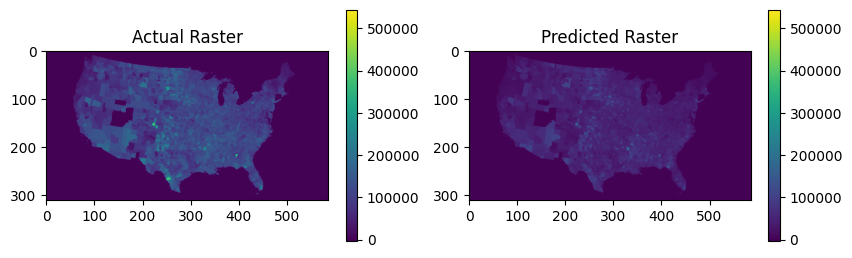

In [26]:
import matplotlib.pyplot as plt

# Visualize predicted vs actual rasters for a specific time step (e.g., the first one)
time_step_to_visualize = 1

original_day = actual_rasters[time_step_to_visualize]
reconstructed_day = predicted_rasters[time_step_to_visualize]
# Find global min and max across both images for color bar normalization
vmin = min(np.min(original_day), np.min(reconstructed_day))
vmax = max(np.max(original_day), np.max(reconstructed_day))

# Plot actual raster
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.imshow(original_day, cmap='viridis', vmin=vmin, vmax=vmax)
plt.colorbar()
plt.title('Actual Raster')

# Plot predicted raster
plt.subplot(1, 2, 2)
plt.imshow(reconstructed_day, cmap='viridis', vmin=vmin, vmax=vmax)
plt.colorbar()
plt.title('Predicted Raster')

plt.show()

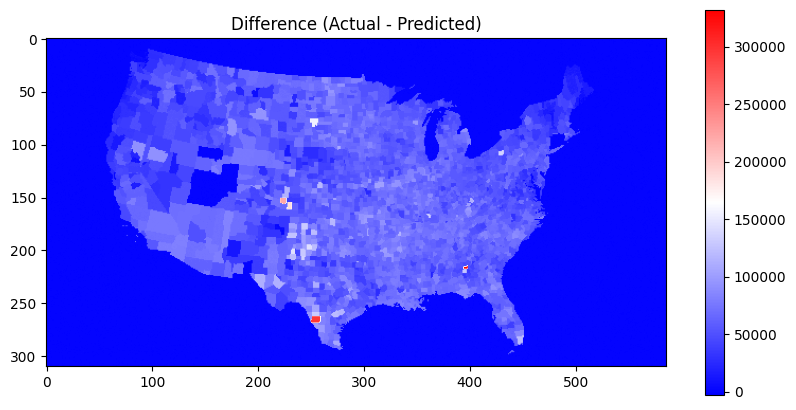

In [27]:
# Visualize the difference between actual and predicted
difference = actual_rasters[time_step_to_visualize] - predicted_rasters[time_step_to_visualize]

plt.figure(figsize=(10, 5))
plt.imshow(difference, cmap='bwr')  # Use a diverging color map to highlight differences
plt.colorbar()
plt.title('Difference (Actual - Predicted)')
plt.show()
